# Pre-processing the dataset:

In [1]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer
from scipy.sparse import hstack

DATASET_PATH = "../datasets"
df = pd.read_csv(f"{DATASET_PATH}/labeled_data/final_training_dataset_ready.csv")

# todo: recency score - figure out a good balance
df["recency_score"] = 1 / ((time.time() - df["mod_time_unix"]) / (90 * 24 * 3600) + 1)
df["size_logged"] = np.log1p(df["size_bytes"])
df["name_len"] = df["filename"].apply(len)
df["path_len"] = df["path"].apply(len)
df["path_depth"] = df["path"].apply(lambda p: p.count("/") + p.count("\\"))

# Initialize HashingVectorizer
hashing_vectorizer = HashingVectorizer(
    n_features=1024,
    analyzer="char",
    norm=None,
    alternate_sign=False,
    ngram_range=(4, 4),
)

# Apply feature hashing to the 'filename' column
filename_vectors = hashing_vectorizer.fit_transform(df["filename"])
path_vectors = hashing_vectorizer.fit_transform(df["path"])

# # Dropping original columns after they've been used for feature creation
# df.drop(
#     ["filename", "path", "extension", "size_bytes", "mod_time_unix"],
#     axis=1,
#     inplace=True,
# )

df

,filename,path,extension,size_bytes,mod_time_unix,source_user,source_type,label_finance,label_hr,label_it,label_general,recency_score,size_logged,name_len,path_len,path_depth
0,api_client.tlog,C:\Program Files\Enterprise Apps\CalendarFromC...,.tlog,1855,1.753322e+09,faker_github_gen,dependency_noise,0,0,0,0,0.355155,7.526179,15,143,16
1,4z3FM53rJmzXdUFm7E7RGtzw0y.lcl,\\wsl$\Debian\home\spencer31\git\JTA-Fork\src\...,.lcl,109679,1.755142e+09,faker_github_gen,dependency_noise,0,0,0,0,0.387344,11.605322,30,119,21
2,CWE590_Free_Memory_Not_on_Heap__delete_array_i...,C:\Temp\Publish\xcc\xcc\test\juliet\testcases\...,.cpp,3088,1.693347e+09,gitlab_runner,github_real,0,0,0,0,0.094980,8.035603,63,80,9
3,bootstrap-4156bd9a.out,\\wsl$\Ubuntu\home\sarah24\projects\malva\malv...,.out,1014,1.747628e+09,faker_github_gen,dependency_noise,0,0,0,0,0.281849,6.922644,22,128,22
4,UIAutomationClient.dll,C:\Windows\assembly\GAC_MSIL\UIAutomationClien...,.dll,167936,1.708022e+09,terry,system_noise,0,0,0,0,0.115723,12.031344,22,73,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2802,PaginatorComponent.php,D:\Websites\downloadsCenter\public_html\vendor...,.php,15385,1.714785e+09,sarah87,github_real,0,0,0,0,0.128673,9.641213,22,87,9
2803,secrets.json,C:\Users\mcclurejamie\Dev\UnitTestingWorkshop,.json,617,1.690985e+09,dev_injector,secret_injection,0,0,1,1,0.092316,6.426488,12,45,4
2804,secrets.json,C:\Users\erica21\Desktop\Coding,.json,502,1.711314e+09,dev_injector,secret_injection,0,0,1,1,0.121684,6.220590,12,31,4
2805,m120.dvi,C:\Users\leachconnie\Documents\Templates,.dvi,73400,1.627050e+09,leachconnie,govdoc_real,0,0,0,0,0.052481,11.203693,8,40,4


# Training:

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define target-specific valuable extensions
target_extension_map = {
    "label_finance": [".xlsx", ".xls", ".csv", ".pdf", ".accp", ".pptx"],
    "label_hr": [".docx", ".doc", ".rtf", ".pdf", ".xlsx", ".xls"],
    "label_it": [
        ".pem",
        ".key",
        ".kdbx",
        ".p12",
        ".ovpn",
        ".private",
        ".wallet",
        ".sql",
        ".env",
    ],
}

# Add "label_general" after defining the other labels
target_extension_map["label_general"] = list(
    set(
        target_extension_map["label_finance"]
        + target_extension_map["label_hr"]
        + target_extension_map["label_it"]
    )
)
common_dev_junk = [
    ".pyc",
    ".pyi",
    ".lcl",
    ".pyd",
    ".map",
    ".ts",
    ".js",
    ".spec",
    ".test.js",
]

# Define target-specific junk extensions
target_junk_map = {
    "label_finance": [".class", ".java", ".cpp", ".obj", ".dll", ".exe"]
    + common_dev_junk,
    "label_hr": [".class", ".java", ".py", ".obj", ".dll", ".exe"] + common_dev_junk,
    "label_it": [".tmp", ".log", ".cache"]
    + [ext for ext in common_dev_junk if ext not in [".ts", ".js"]],
}

target_junk_map["label_general"] = list(
    set(
        target_junk_map["label_finance"]
        + target_junk_map["label_hr"]
        + target_junk_map["label_it"]
    )
)


models_map = {}

for target in {"label_general", "label_it", "label_finance", "label_hr"}:

    # Prepare Data
    df_temp = df.copy()
    df_temp["valuable_ext"] = df_temp["extension"].isin(target_extension_map[target]).astype(int)
    df_temp["junk_ext"] = df_temp["extension"].isin(target_junk_map[target]).astype(int)

    df_temp.to_csv("1.csv", index=False)

    # Create feature matrix X and target vector y for the current target
    numerical_features = df_temp[
        [
            "recency_score",
            "size_logged",
            "valuable_ext",
            "junk_ext",
            "name_len",
            "path_len",
            "path_depth",
        ]
    ].values
    X_target = hstack([numerical_features, filename_vectors, path_vectors])
    y_target = df_temp[target].values

    # Split Data
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_target, y_target, df_temp.index, test_size=0.2, random_state=42, stratify=y_target
    )

    # Train Model
    model = LogisticRegression(solver="lbfgs", max_iter=1000, C=0.1, class_weight="balanced")
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]

    print("Accuracy for", target, ":", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    models_map[target] = model

Accuracy for label_hr : 0.9501779359430605

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97       529
           1       0.54      0.94      0.69        33

    accuracy                           0.95       562
   macro avg       0.77      0.95      0.83       562
weighted avg       0.97      0.95      0.96       562

Accuracy for label_general : 0.891459074733096

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.92       406
           1       0.80      0.82      0.81       156

    accuracy                           0.89       562
   macro avg       0.86      0.87      0.87       562
weighted avg       0.89      0.89      0.89       562

Accuracy for label_finance : 0.9501779359430605

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97       533
           1       0.51 

Top results for model targeting label_hr:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
234,Recruiter_Workload.xlsx,C:\Users\sara02\Documents\HR\Recruiting\Metrics,.xlsx,41943,23,47,6,1.706096e+09,chatGPT_HR,1,0.986021
307,Candidate_Stats_Q1.xlsx,C:\Users\phillipbolton\Documents\HR\Recruiting...,.xlsx,41943,23,54,6,1.703981e+09,chatGPT_HR,1,0.985498
7,Candidate_Shortlist_Export.xls,Z:\HR\Recruiting\Reqs\2025\Exports,.xls,20971,30,34,5,1.702991e+09,chatGPT_HR,1,0.960573
237,Recruitment_Funnel_2023_FINAL.xlsx,Z:\HR\Recruiting\Reports\Archive,.xlsx,157286,34,32,4,1.684772e+09,chatGPT_HR,1,0.949150
83,Recruitment_Backlog.xlsx,C:\Users\emily49\Documents\HR\Recruiting,.xlsx,62914,24,40,5,1.704011e+09,chatGPT_HR,1,0.945538
117,Employee costs.xlsx,C:\Users\hubbardkimberly\Documents,.xlsx,188743,19,34,3,1.706121e+09,chatGPT_HR,1,0.932246
128,EmployeeMaster_v0.xlsx,F:\CorpShare\MiscExports,.xlsx,262144,22,24,2,1.708452e+09,chatGPT_HR,1,0.930076
222,salary stuff.xlsx,C:\Users\ybrown\Downloads,.xlsx,52428,17,25,3,1.700560e+09,chatGPT_HR,1,0.923626
231,TABLE 3.2 Screen_Perched rev3.doc,Z:\HR\Recruiting\Reqs\2024\Screen,.doc,20971,33,33,5,1.678799e+09,govdoc_real,1,0.923075
176,Hiring_Plan_By_Department.xlsx,C:\Users\marygonzalez\Documents\HR\Planning,.xlsx,73400,30,43,5,1.708126e+09,chatGPT_HR,1,0.913282


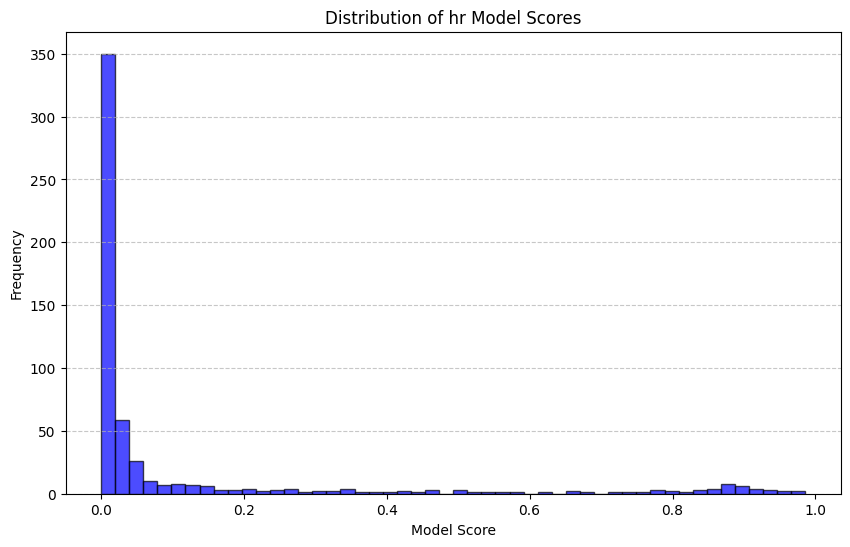

Top results for model targeting label_general:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
521,client_secret.json,C:\Users\julia27\Desktop\Code_Review,.json,1842,18,36,4,1.704910e+09,secret_injection,1,0.995517
494,config.py,C:\Users\karenbarnes\source\repos\config,.py,2495,9,40,5,1.706805e+09,secret_injection,1,0.992497
30,certificate.p12,C:\Users\ricardo01\source\repos\SiegeUnitConve...,.p12,50585,15,53,5,1.721267e+09,secret_injection,1,0.991022
363,kubeconfig.yaml,C:\Users\xestrada\source\repos\config,.yaml,1314,15,37,5,1.707342e+09,secret_injection,1,0.988206
310,secrets.json,\\wsl$\Ubuntu\home\runner\auth-service,.json,282,12,38,6,1.711621e+09,secret_injection,1,0.984744
170,FY25_Payroll_Forecast_v3.xlsx,Z:\HR\Payroll\Forecasts,.xlsx,188743,29,23,3,1.707449e+09,chatGPT_HR,1,0.983352
31,credentials.json,C:\Users\melissa84\source\repos,.json,3888,16,31,4,1.692149e+09,secret_injection,1,0.980062
462,database.php,C:\Work\Projects\Bio-HMM-Logo\src\config,.php,2643,12,40,5,1.696114e+09,secret_injection,1,0.979300
298,web.config,C:\Users\ehunter\source\repos\config,.config,971,10,36,5,1.730152e+09,secret_injection,1,0.978829
58,config.py,C:\Users\kwatkins\source\repos,.py,240,9,30,4,1.697694e+09,secret_injection,1,0.978493


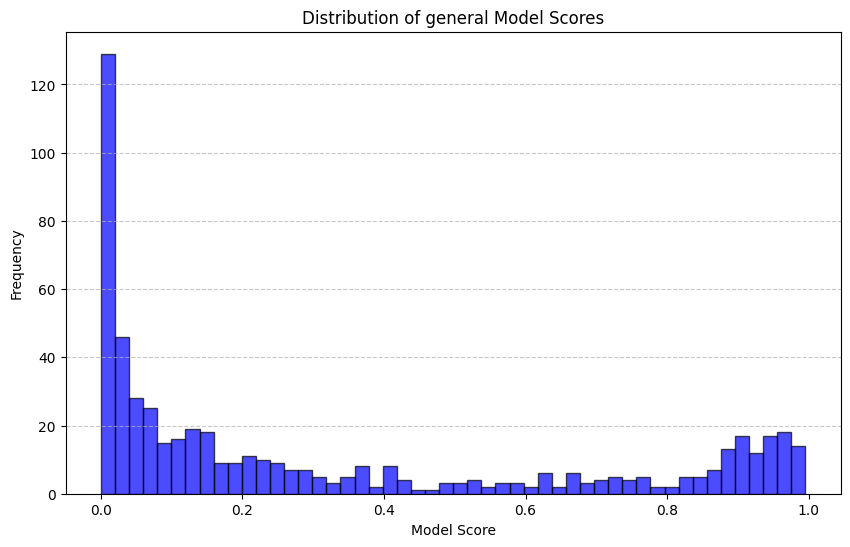

Top results for model targeting label_finance:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
170,FY25_Payroll_Forecast_v3.xlsx,Z:\HR\Payroll\Forecasts,.xlsx,188743,29,23,3,1.707449e+09,chatGPT_HR,1,0.999783
283,TE - 13 GDC NSN Listing (Complete).xlsx,Z:\HR\Payroll\Cycles\2024\Listing,.xlsx,283115,39,33,5,1.709760e+09,govdoc_real,1,0.985730
523,budget_final_really_final.xlsx,C:\Users\jbarnes\Desktop,.xlsx,734003,30,24,3,1.703744e+09,chatGPT_finance,1,0.983395
21,WDKY-TV - COMPREHENSIVE TECHNIC.pdf,Z:\HR\Payroll\Cycles\2023,.pdf,2044723,35,25,4,1.708041e+09,govdoc_real,1,0.970687
546,Payroll_Exception_Report.xls,C:\Users\ybrown\Documents\HR\Payroll\Exceptions,.xls,31457,28,47,6,1.700560e+09,chatGPT_HR,1,0.969508
430,Vista_and_office_07_Compatibility 2 12 08.doc,Z:\HR\Payroll\Cycles\2023\Vista,.doc,157286,45,31,5,1.675936e+09,govdoc_real,1,0.969085
84,Payroll final maybe.xlsx,C:\Users\ybrown\Desktop,.xlsx,73400,24,23,3,1.700559e+09,chatGPT_HR,1,0.959313
416,Detailed Compromise Summary for web 9-28-05.docx,Z:\HR\Payroll\Cycles\2024\Docx,.docx,167772,49,30,5,1.694878e+09,govdoc_real,1,0.958637
517,cash forecast temp.xlsx,C:\Users\patricia94\Documents\Finance\temp,.xlsx,314572,23,42,5,1.702849e+09,chatGPT_finance,1,0.957644
280,CompAdjustmentsLog.xls,E:\Notes\Payroll\Misc,.xls,52428,22,21,3,1.698330e+09,chatGPT_HR,1,0.948309


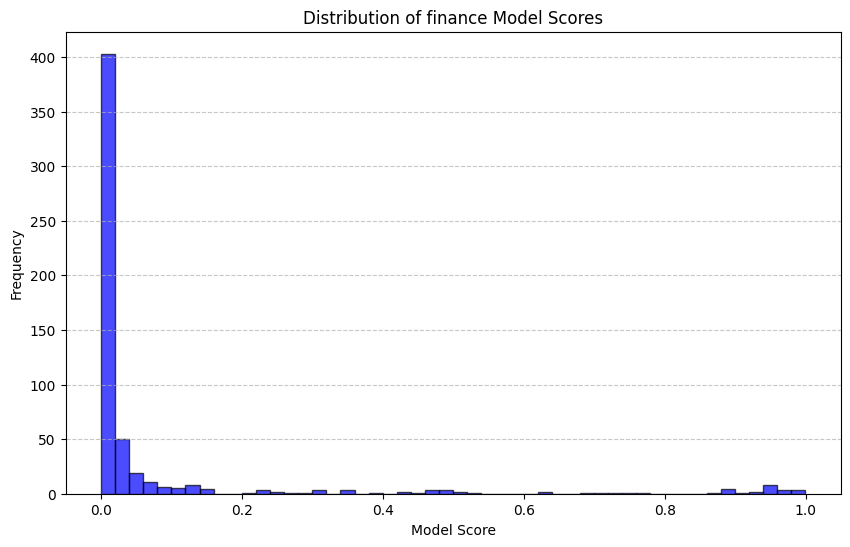

Top results for model targeting label_it:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
310,secrets.json,\\wsl$\Ubuntu\home\runner\auth-service,.json,282,12,38,6,1.711621e+09,secret_injection,1,0.993982
521,client_secret.json,C:\Users\julia27\Desktop\Code_Review,.json,1842,18,36,4,1.704910e+09,secret_injection,1,0.993207
30,certificate.p12,C:\Users\ricardo01\source\repos\SiegeUnitConve...,.p12,50585,15,53,5,1.721267e+09,secret_injection,1,0.992233
124,auth.json,C:\Users\zporter\Desktop\Coding,.json,2249,9,31,4,1.734920e+09,secret_injection,1,0.991262
494,config.py,C:\Users\karenbarnes\source\repos\config,.py,2495,9,40,5,1.706805e+09,secret_injection,1,0.991023
298,web.config,C:\Users\ehunter\source\repos\config,.config,971,10,36,5,1.730152e+09,secret_injection,1,0.989909
22,users.sql,C:\Users\nicole33\Desktop\Code_Review\apdpln\l...,.sql,110335,9,56,7,1.698385e+09,secret_injection,1,0.988257
312,dump.sql,C:\Users\nicole33\source\repos\jenadin-test\te...,.sql,5673,8,55,7,1.696735e+09,github_real,1,0.988181
58,config.py,C:\Users\kwatkins\source\repos,.py,240,9,30,4,1.697694e+09,secret_injection,1,0.987876
264,secrets.js,C:\Users\sharon66\Desktop\Coding\config,.js,1072,10,39,5,1.716635e+09,secret_injection,1,0.987615


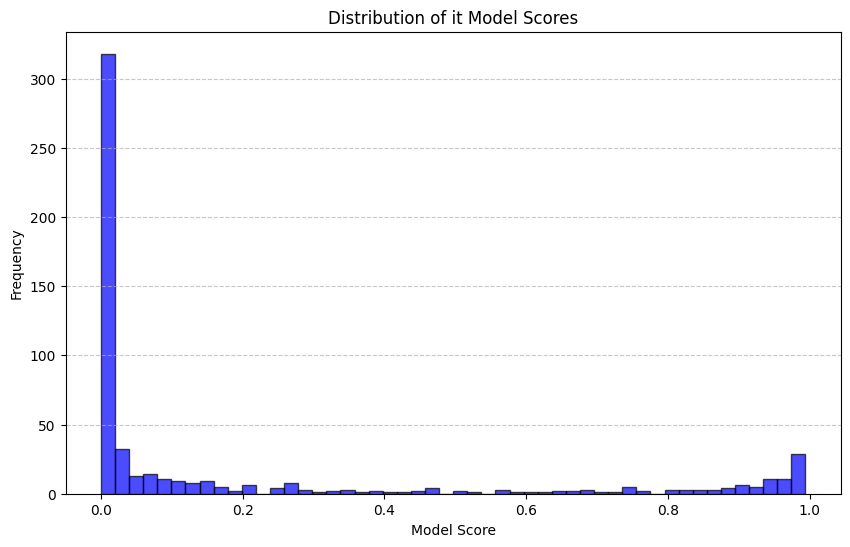

In [8]:
import matplotlib.pyplot as plt

for target, model in models_map.items():
    print(f"Top results for model targeting {target}:")

    # Get test set predictions
    y_test = df.loc[idx_test][target].values
    y_scores = model.predict_proba(X_test)[:, 1]

    results = pd.DataFrame(
        {
            "filename": df.loc[idx_test]["filename"].values,
            "filepath": df.loc[idx_test]["path"].values,
            "extension": df.loc[idx_test]["extension"].values,
            "size_bytes": df.loc[idx_test]["size_bytes"].values,
            "name_len": df.loc[idx_test]["name_len"].values,
            "path_len": df.loc[idx_test]["path_len"].values,
            "path_depth": df.loc[idx_test]["path_depth"].values,
            "mod_time_unix": df.loc[idx_test]["mod_time_unix"].values,
            "source_label": df.loc[idx_test]["source_type"].values,
            "actual_label": y_test,
            "model_score": y_scores,
        }
    )

    # Sort and slice the results
    sorted_results = results.sort_values(by="model_score", ascending=False)
    display(sorted_results[:10])

    # Plot the distribution of model scores
    plt.figure(figsize=(10, 6))
    plt.hist(
        results["model_score"], bins=50, color="blue", alpha=0.7, edgecolor="black"
    )
    plt.title(f"Distribution of {target.split("_")[1]} Model Scores")
    plt.xlabel("Model Score")
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# Exporting weights:

In [9]:
import os

output_path = f"../include/ModelWeights.h"

# 3. Ensure Directory Exists and Write
os.makedirs(os.path.dirname(output_path), exist_ok=True)

cpp_content = f"""
#pragma once
// AUTOMATICALLY GENERATED FILE 

#include <vector>
#include <unordered_set>
#include <string>
# """

for target, model in models_map.items():

    # Extract Parameters
    bias = model.intercept_[0]
    weights = model.coef_.flatten()
    title = target.split("_")[1].upper()
    cpp_content += f"""
const double {title}_MODEL_BIAS = {bias:.10f};

// recency score - size_logged - valuable_ext -  junk_ext - name_len - path_len - path_depth - filename features(1024) - path features(1024)
const std::vector<double> {title}_MODEL_WEIGHTS = {{
{', '.join([f'{w:.10f}' for w in weights])}}};

const std::unordered_set<std::wstring> {title}_HIGH_VAL_EXTS = {{
{', '.join([f'L"{ext}"' for ext in target_extension_map[target]])}}};

const std::unordered_set<std::wstring> {title}_JUNK_EXTS = {{
{', '.join([f'L"{ext}"' for ext in target_junk_map[target]])}}};
"""

with open(output_path, "w") as f:
    f.write(cpp_content)